<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




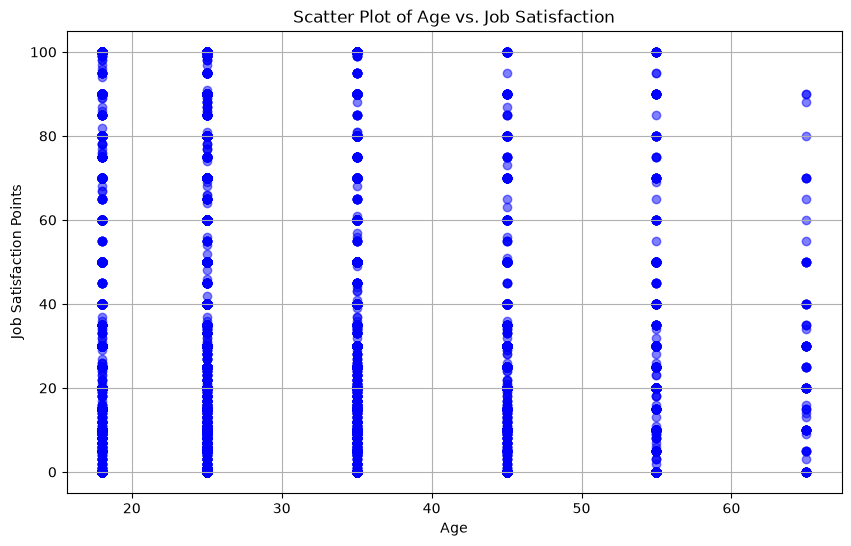

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir las columnas a numéricas limpiando posibles datos de texto
df['Age_num'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['JobSatPoints_6_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Eliminar nulos
df_plot1 = df.dropna(subset=['Age_num', 'JobSatPoints_6_num'])

plt.figure(figsize=(10, 6))
plt.scatter(df_plot1['Age_num'], df_plot1['JobSatPoints_6_num'], alpha=0.5, color='b')
plt.title('Scatter Plot of Age vs. Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction Points')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


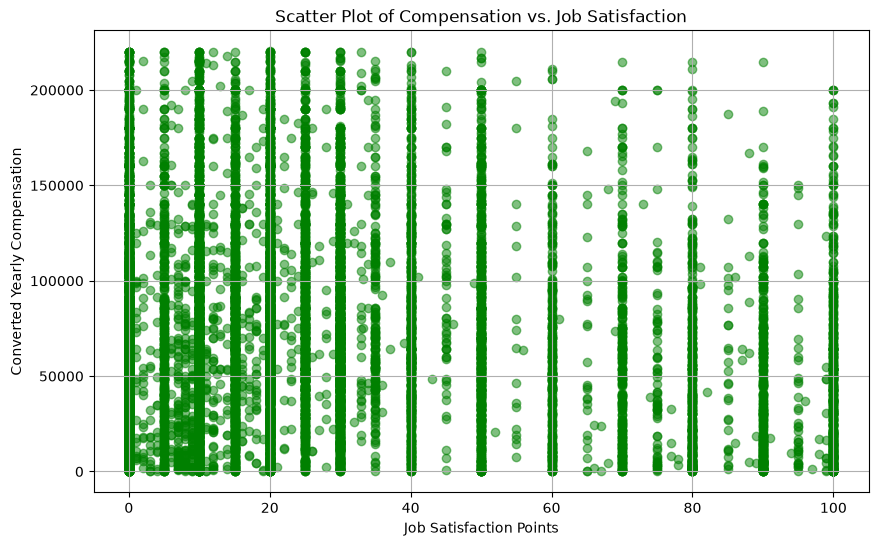

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir columnas a numéricas
df['ConvertedCompYearly_num'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Filtrar outliers extremos para que la dispersión sea clara y visible
Q1 = df['ConvertedCompYearly_num'].quantile(0.25)
Q3 = df['ConvertedCompYearly_num'].quantile(0.75)
IQR = Q3 - Q1
df_plot2 = df[(df['ConvertedCompYearly_num'] >= (Q1 - 1.5 * IQR)) & (df['ConvertedCompYearly_num'] <= (Q3 + 1.5 * IQR))]

plt.figure(figsize=(10, 6))
plt.scatter(df_plot2['JobSatPoints_6_num'], df_plot2['ConvertedCompYearly_num'], alpha=0.5, color='g')
plt.title('Scatter Plot of Compensation vs. Job Satisfaction')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Converted Yearly Compensation')
plt.grid(True)
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


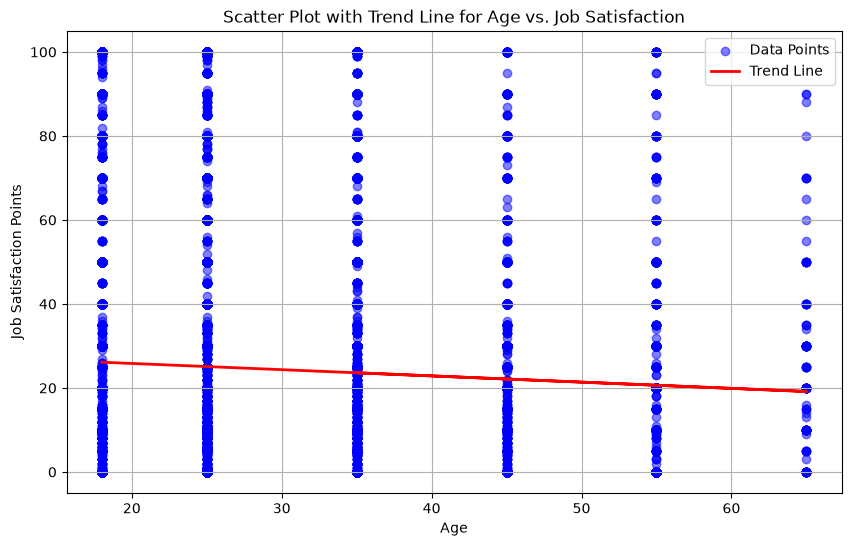

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convertir las columnas a numéricas
df['Age_num'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['JobSatPoints_6_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Eliminar filas con valores nulos
data = df[['Age_num', 'JobSatPoints_6_num']].dropna()

# Calcular la línea de regresión (tendencia)
m, b = np.polyfit(data['Age_num'], data['JobSatPoints_6_num'], 1)

plt.figure(figsize=(10, 6))
plt.scatter(data['Age_num'], data['JobSatPoints_6_num'], alpha=0.5, color='blue', label='Data Points')
plt.plot(data['Age_num'], m * data['Age_num'] + b, color='red', linewidth=2, label='Trend Line')

plt.title('Scatter Plot with Trend Line for Age vs. Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction Points')
plt.legend()
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


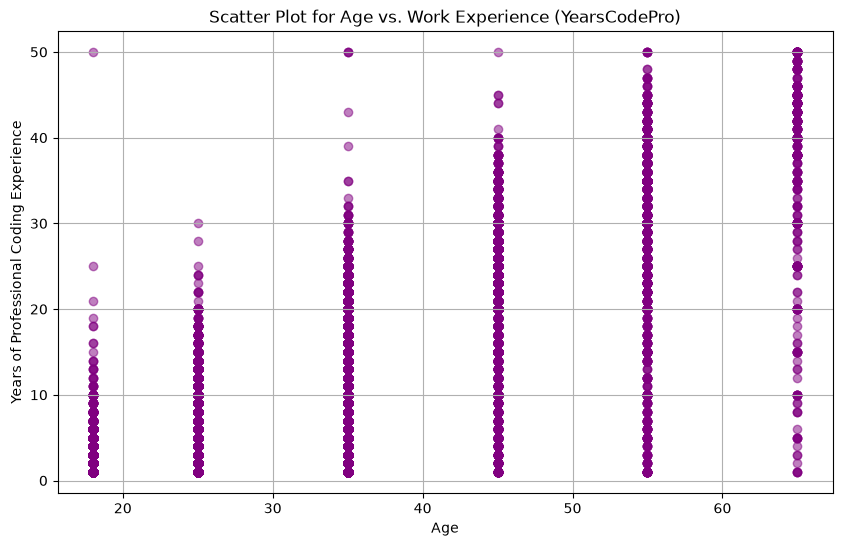

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir las columnas a numéricas
df['Age_num'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['YearsCodePro_num'] = pd.to_numeric(df['YearsCodePro'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Eliminar nulos
data = df[['Age_num', 'YearsCodePro_num']].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(data['Age_num'], data['YearsCodePro_num'], alpha=0.5, color='purple')
plt.title('Scatter Plot for Age vs. Work Experience (YearsCodePro)')
plt.xlabel('Age')
plt.ylabel('Years of Professional Coding Experience')
plt.grid(True)
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


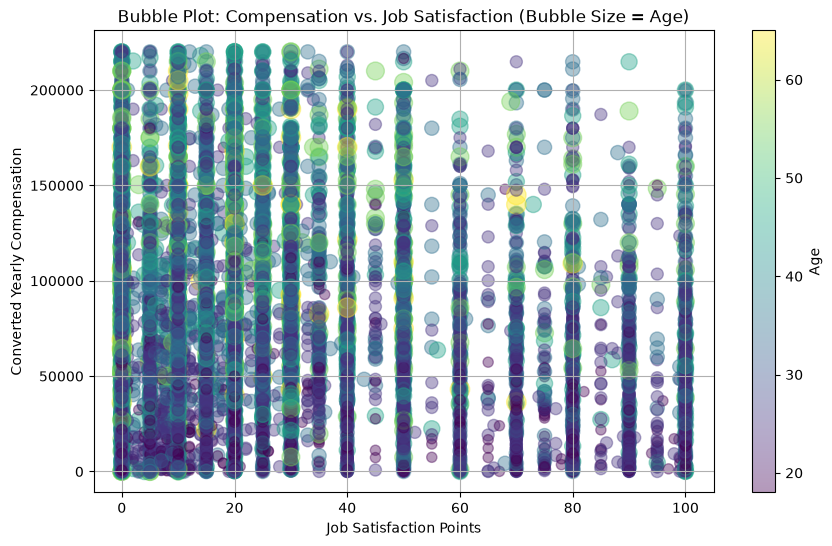

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir columnas
df['ConvertedCompYearly_num'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['Age_num'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Filtrar outliers de compensación para mantener una escala clara
Q1 = df['ConvertedCompYearly_num'].quantile(0.25)
Q3 = df['ConvertedCompYearly_num'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['ConvertedCompYearly_num'] >= (Q1 - 1.5 * IQR)) & (df['ConvertedCompYearly_num'] <= (Q3 + 1.5 * IQR))]

# Eliminar filas con nulos en las 3 variables requeridas
data = df_filtered[['JobSatPoints_6_num', 'ConvertedCompYearly_num', 'Age_num']].dropna()

plt.figure(figsize=(10, 6))
# El tamaño de la burbuja 's' se escala proporcionalmente a la edad
plt.scatter(
    data['JobSatPoints_6_num'], 
    data['ConvertedCompYearly_num'], 
    s=data['Age_num'] * 3, 
    alpha=0.4, 
    c=data['Age_num'], 
    cmap='viridis'
)

plt.title('Bubble Plot: Compensation vs. Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Converted Yearly Compensation')
plt.colorbar(label='Age')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


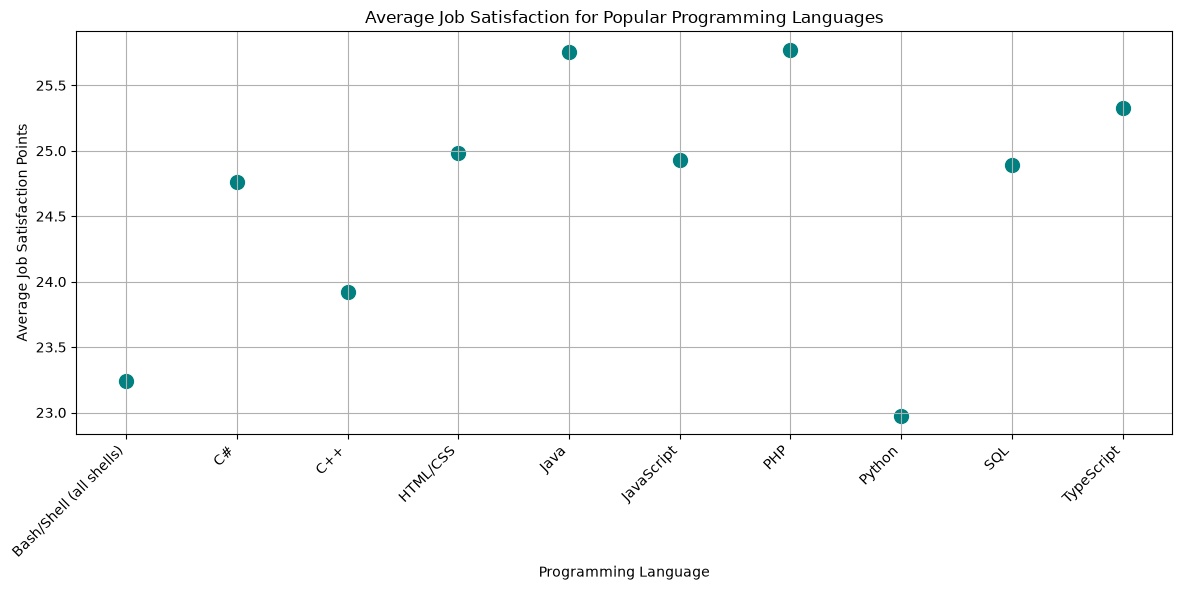

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparar datos
df['JobSatPoints_6_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Separar lenguajes (LanguageHaveWorkedWith)
data_lang = df[['LanguageHaveWorkedWith', 'JobSatPoints_6_num']].dropna()
data_lang['Language'] = data_lang['LanguageHaveWorkedWith'].astype(str).str.split(';')
data_exploded = data_lang.explode('Language')

# 2. Seleccionar los Top 10 lenguajes más populares
top10_langs = data_exploded['Language'].value_counts().head(10).index.tolist()
df_top_langs = data_exploded[data_exploded['Language'].isin(top10_langs)]

# 3. Calcular la satisfacción promedio por lenguaje para un gráfico claro
lang_sat = df_top_langs.groupby('Language')['JobSatPoints_6_num'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.scatter(lang_sat['Language'], lang_sat['JobSatPoints_6_num'], color='teal', s=100)

plt.title('Average Job Satisfaction for Popular Programming Languages')
plt.xlabel('Programming Language')
plt.ylabel('Average Job Satisfaction Points')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


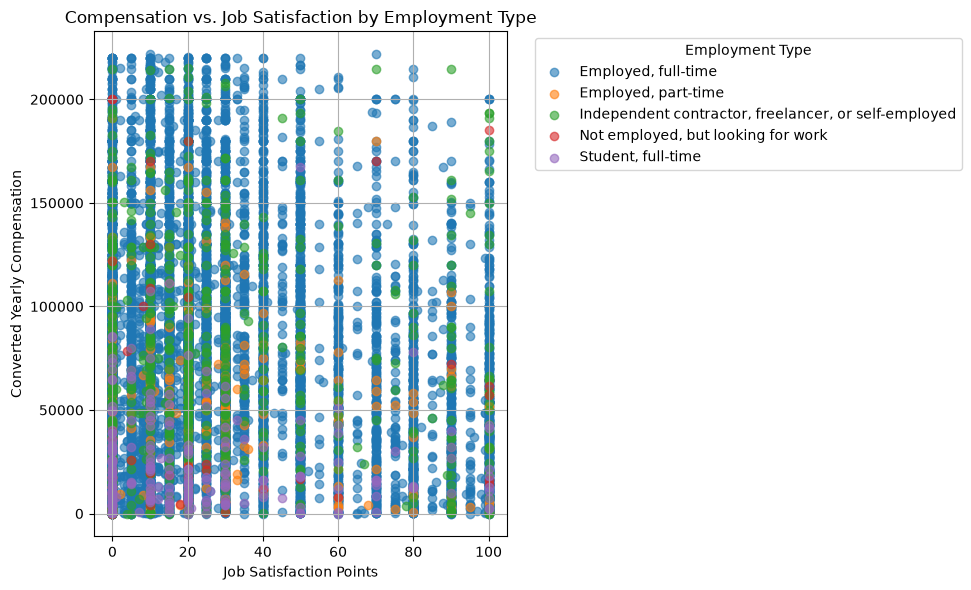

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir variables a numéricas
df['ConvertedCompYearly_num'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6_num'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Limpiar los tipos de empleo extrayendo la categoría principal
df['Employment_Clean'] = df['Employment'].dropna().astype(str).str.split(';').str[0]

# Seleccionar los Top 5 tipos de empleo para mantener la leyenda legible
top_emp = df['Employment_Clean'].value_counts().head(5).index.tolist()
df_filtered = df[df['Employment_Clean'].isin(top_emp)].copy()

# Filtrar outliers de compensación para mantener una buena escala
Q1 = df_filtered['ConvertedCompYearly_num'].quantile(0.25)
Q3 = df_filtered['ConvertedCompYearly_num'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df_filtered[(df_filtered['ConvertedCompYearly_num'] >= (Q1 - 1.5 * IQR)) & 
                          (df_filtered['ConvertedCompYearly_num'] <= (Q3 + 1.5 * IQR))]

plt.figure(figsize=(10, 6))

# Agrupar y graficar con colores distintos
for emp_type, group in df_filtered.groupby('Employment_Clean'):
    plt.scatter(group['JobSatPoints_6_num'], group['ConvertedCompYearly_num'], label=emp_type, alpha=0.6)

plt.title('Compensation vs. Job Satisfaction by Employment Type')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Converted Yearly Compensation')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


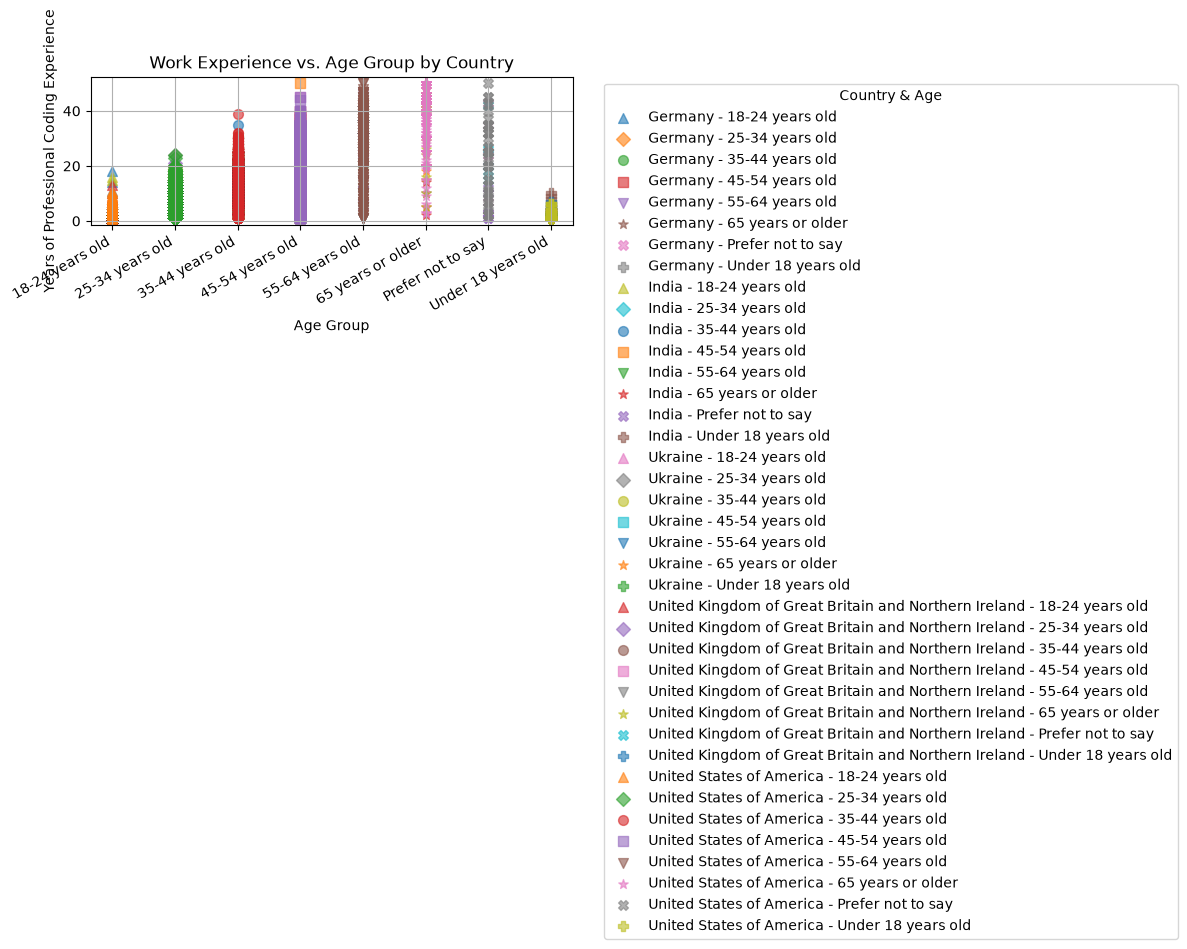

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir YearsCodePro a numérico
df['YearsCodePro_num'] = pd.to_numeric(df['YearsCodePro'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Seleccionar los Top 5 países más frecuentes
top_countries = df['Country'].value_counts().head(5).index.tolist()
df_top = df[df['Country'].isin(top_countries)].dropna(subset=['YearsCodePro_num', 'Age', 'Country']).copy()

# Mapear marcadores para los diferentes grupos de edad
age_groups = df_top['Age'].unique()
markers = ['o', 's', '^', 'D', 'v', '*', 'P', 'X']
marker_dict = {age: markers[i % len(markers)] for i, age in enumerate(age_groups)}

plt.figure(figsize=(12, 6))

# Graficar agrupando por País (Color) y Edad (Marcador)
for country, c_group in df_top.groupby('Country'):
    for age, a_group in c_group.groupby('Age'):
        plt.scatter(
            a_group['Age'], 
            a_group['YearsCodePro_num'], 
            label=f"{country} - {age}", 
            marker=marker_dict[age], 
            alpha=0.6, 
            s=50
        )

plt.title('Work Experience vs. Age Group by Country')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Coding Experience')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Country & Age', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
